In [20]:
import time
import warnings
from itertools import cycle, islice

import matplotlib.pyplot as plt
import numpy as np

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler

# STEP 1: on génère le dataset

In [21]:
# ============
# Generate datasets. We choose the size big enough to see the scalability
# of the algorithms, but not too big to avoid too long running times
# ============
n_samples = 500
seed = 30
noisy_circles = datasets.make_circles(
    n_samples=n_samples, factor=0.5, noise=0.05, random_state=seed
)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=seed)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=seed)
rng = np.random.RandomState(seed)
no_structure = rng.rand(n_samples, 2), None

# Anisotropicly distributed data
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# blobs with varied variances
varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)

# STEP 2 : on définit les paramètres des clusters

In [22]:
# ============
# Set up cluster parameters
# ============
plt.figure(figsize=(20, 15))
plt.subplots_adjust(
    left=0.02, right=0.98, bottom=0.001, top=0.95, wspace=0.05, hspace=0.01
)

plot_num = 1

default_base = {
    "quantile": 0.3,
    "eps": 0.3,
    "damping": 0.9,
    "preference": -200,
    "n_neighbors": 3,
    "n_clusters": 3,
    "min_samples": 7,
    "xi": 0.05,
    "min_cluster_size": 0.1,
    "allow_single_cluster": True,
    "hdbscan_min_cluster_size": 15,
    "hdbscan_min_samples": 3,
    "random_state": 42,
}

datasets = [
    (
        noisy_circles,
        {
            "damping": 0.77,
            "preference": -240,
            "quantile": 0.2,
            "n_clusters": 2,
            "min_samples": 7,
            "xi": 0.08,
        },
    ),
    (
        noisy_moons,
        {
            "damping": 0.75,
            "preference": -220,
            "n_clusters": 2,
            "min_samples": 7,
            "xi": 0.1,
        },
    ),
    (
        varied,
        {
            "eps": 0.18,
            "n_neighbors": 2,
            "min_samples": 7,
            "xi": 0.01,
            "min_cluster_size": 0.2,
        },
    ),
    (
        aniso,
        {
            "eps": 0.15,
            "n_neighbors": 2,
            "min_samples": 7,
            "xi": 0.1,
            "min_cluster_size": 0.2,
        },
    ),
    (blobs, {"min_samples": 7, "xi": 0.1, "min_cluster_size": 0.2}),
    (no_structure, {}),
]

for i_dataset, (dataset, algo_params) in enumerate(datasets):
    # update parameters with dataset-specific values
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset

    # normalize dataset for easier parameter selection
    X = StandardScaler().fit_transform(X)

    # estimate bandwidth for mean shift
    bandwidth = cluster.estimate_bandwidth(X, quantile=params["quantile"])

    # connectivity matrix for structured Ward
    connectivity = kneighbors_graph(
        X, n_neighbors=params["n_neighbors"], include_self=False
    )
    # make connectivity symmetric
    connectivity = 0.5 * (connectivity + connectivity.T)

<Figure size 2000x1500 with 0 Axes>

# STEP 3 : on définit les paramètres des différents algo de clustering puis on les visualise sur différentes géométries de données

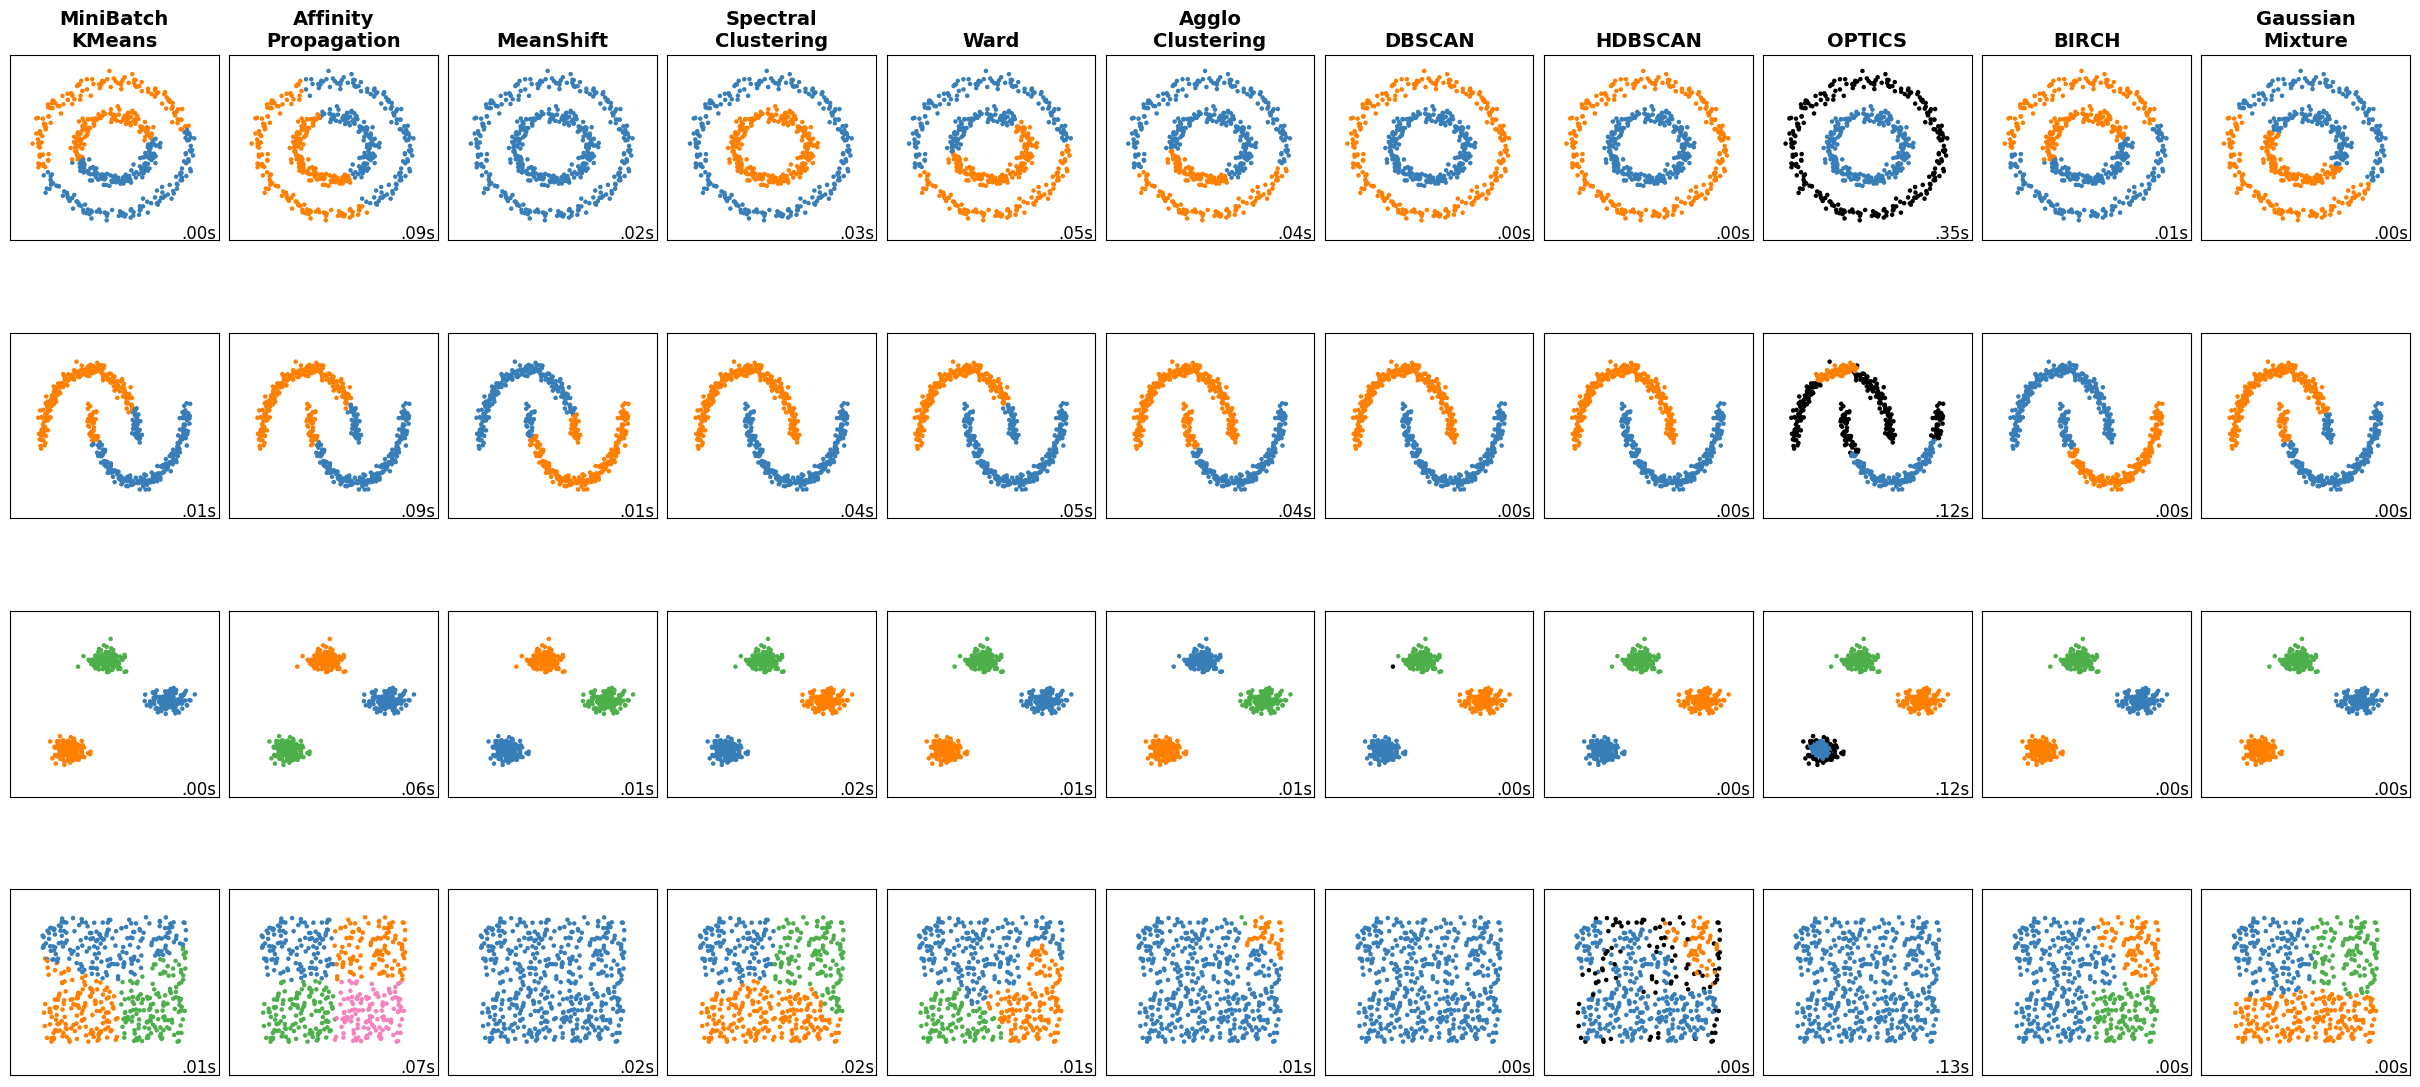

In [27]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle, islice
from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler

# ============
# 1. Préparation des Datasets
# ============
n_samples = 500
seed = 42
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05, random_state=seed)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=seed)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=seed)
no_structure = np.random.rand(n_samples, 2), None

# On crée une liste de datasets avec des paramètres spécifiques pour certains algos
datasets = [
    (noisy_circles, {"n_clusters": 2, "eps": 0.3, "damping": .77, "preference": -240,
                     "hdbscan_min_samples": 7, "hdbscan_min_cluster_size": 15, "allow_single_cluster": False,
                     "min_samples": 20, "xi": 0.05, "min_cluster_size": 0.1}),
    (noisy_moons, {"n_clusters": 2, "eps": 0.3, "damping": .75, "preference": -220,
                   "hdbscan_min_samples": 10, "hdbscan_min_cluster_size": 20, "allow_single_cluster": False,
                   "min_samples": 20, "xi": 0.05, "min_cluster_size": 0.1}),
    (blobs, {"n_clusters": 3, "eps": 0.3, "damping": .9, "preference": -200,
             "hdbscan_min_samples": 10, "hdbscan_min_cluster_size": 20, "allow_single_cluster": False,
             "min_samples": 20, "xi": 0.05, "min_cluster_size": 0.1}),
    (no_structure, {"n_clusters": 3, "eps": 0.3, "damping": .9, "preference": -200,
                    "hdbscan_min_samples": 10, "hdbscan_min_cluster_size": 20, "allow_single_cluster": False,
                    "min_samples": 20, "xi": 0.05, "min_cluster_size": 0.1})
]

# ============
# 2. Configuration de la Figure (Taille XL pour 11 colonnes)
# ============
plt.figure(figsize=(25, 12))
plt.subplots_adjust(left=.02, right=.98, bottom=.05, top=.90, wspace=.05, hspace=.50)

plot_num = 1

for i_dataset, (dataset, params) in enumerate(datasets):
    X, y = dataset
    X = StandardScaler().fit_transform(X)

    # Création des objets (nécessaire à chaque tour pour la connectivité)
    bandwidth = cluster.estimate_bandwidth(X, quantile=0.3)
    connectivity = kneighbors_graph(X, n_neighbors=params["n_clusters"], include_self=False)
    connectivity = 0.5 * (connectivity + connectivity.T)

    ms = cluster.MeanShift(bandwidth=bandwidth, bin_seeding=True)
    two_means = cluster.MiniBatchKMeans(n_clusters=params["n_clusters"], n_init="auto")
    ward = cluster.AgglomerativeClustering(n_clusters=params["n_clusters"], linkage="ward", connectivity=connectivity)
    spectral = cluster.SpectralClustering(n_clusters=params["n_clusters"], eigen_solver="arpack", affinity="nearest_neighbors")
    dbscan = cluster.DBSCAN(eps=params["eps"])
    hdbscan = cluster.HDBSCAN(min_samples=params["hdbscan_min_samples"], min_cluster_size=params["hdbscan_min_cluster_size"])
    optics = cluster.OPTICS(min_samples=params["min_samples"], xi=params["xi"], min_cluster_size=params["min_cluster_size"])
    affinity_propagation = cluster.AffinityPropagation(damping=params["damping"], preference=params["preference"], random_state=0)
    average_linkage = cluster.AgglomerativeClustering(linkage="average", metric="cityblock", n_clusters=params["n_clusters"], connectivity=connectivity)
    birch = cluster.Birch(n_clusters=params["n_clusters"])
    gmm = mixture.GaussianMixture(n_components=params["n_clusters"], covariance_type="full")

    clustering_algorithms = (
        ("MiniBatch\nKMeans", two_means),
        ("Affinity\nPropagation", affinity_propagation),
        ("MeanShift", ms),
        ("Spectral\nClustering", spectral),
        ("Ward", ward),
        ("Agglo\nClustering", average_linkage),
        ("DBSCAN", dbscan),
        ("HDBSCAN", hdbscan),
        ("OPTICS", optics),
        ("BIRCH", birch),
        ("Gaussian\nMixture", gmm),
    )

    for name, algorithm in clustering_algorithms:
        t0 = time.time()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            algorithm.fit(X)
        t1 = time.time()

        if hasattr(algorithm, "labels_"):
            y_pred = algorithm.labels_.astype(int)
        else:
            y_pred = algorithm.predict(X)

        plt.subplot(len(datasets), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=14, fontweight="bold")

        colors = np.array(list(islice(cycle(["#377eb8", "#ff7f00", "#4daf4a", "#f781bf", "#a65628", "#984ea3", "#999999", "#e41a1c", "#dede00"]), int(max(y_pred) + 1))))
        colors = np.append(colors, ["#000000"])
        
        plt.scatter(X[:, 0], X[:, 1], s=5, color=colors[y_pred])

        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        plt.text(.99, .01, ("%.2fs" % (t1 - t0)).lstrip("0"), transform=plt.gca().transAxes, size=12, horizontalalignment="right")
        plot_num += 1

plt.show()

# STEP 4: autre visualisation pour Minibatch (k-means), Gaussian Mixture et DBSCAN

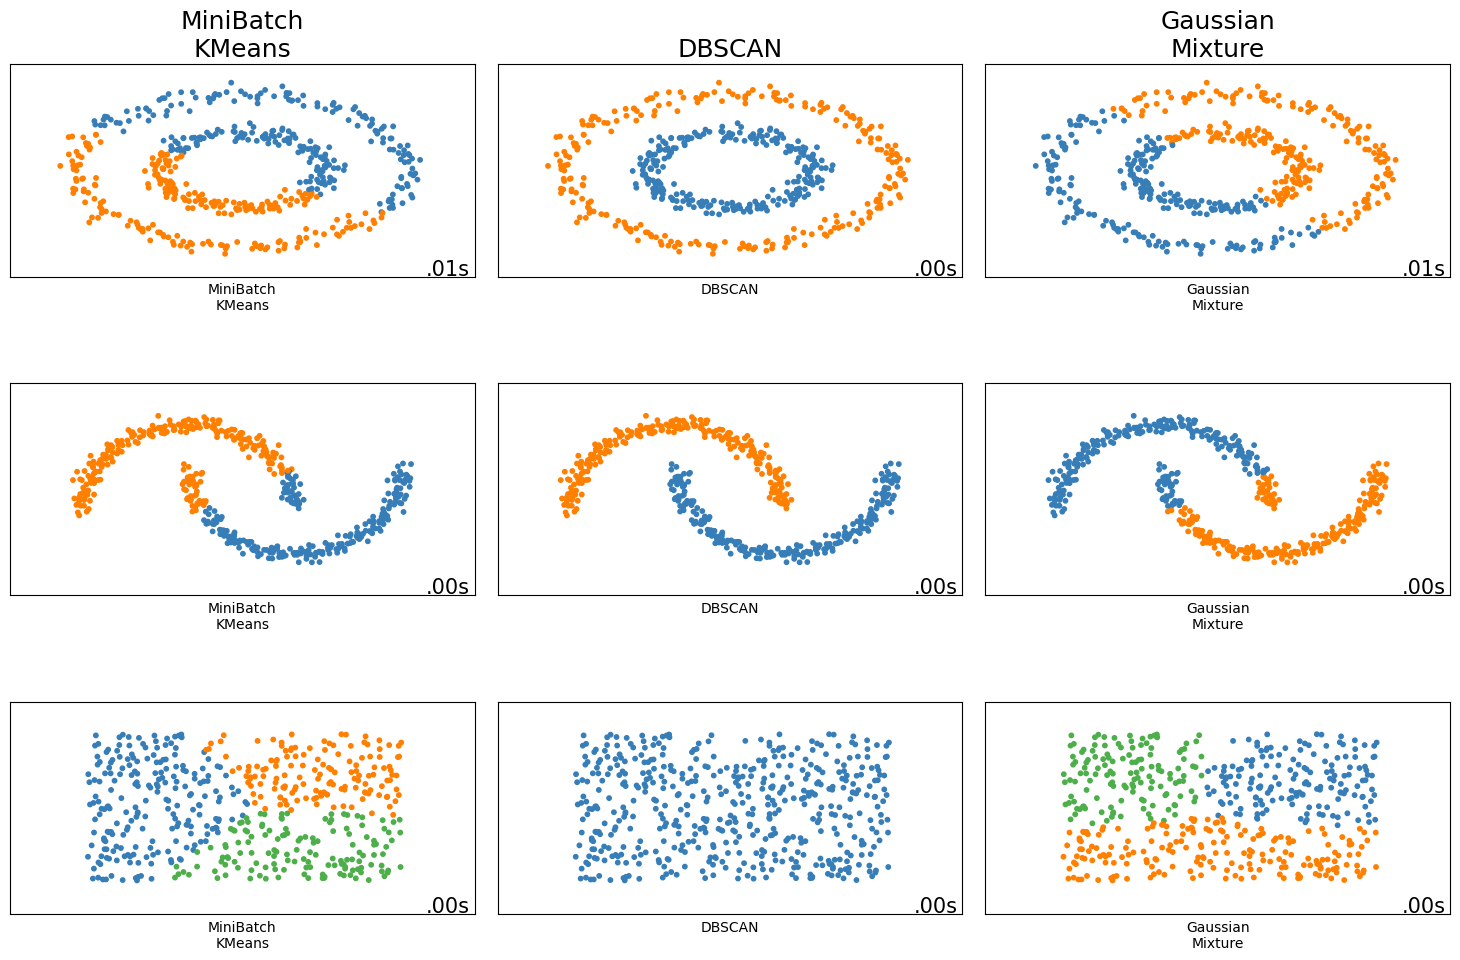

In [26]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle, islice
from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler

# 1. On prépare les données (les fameuses formes : cercles, lunes, etc.)
n_samples = 500
seed = 42
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05, random_state=seed)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=seed)
no_structure = np.random.rand(n_samples, 2), None

list_datasets = [
    (noisy_circles, {"n_clusters": 2, "eps": 0.3}),
    (noisy_moons, {"n_clusters": 2, "eps": 0.3}),
    (no_structure, {"n_clusters": 3, "eps": 0.3})
]

# 2. CONFIGURATION DE LA FIGURE (On prépare une grande zone de dessin)
plt.figure(figsize=(15, 10))
plt.subplots_adjust(left=.02, right=.98, bottom=.05, top=.90, wspace=.05, hspace=.50)

plot_num = 1

# BOUCLE 1 : On passe sur chaque forme de données
for i_dataset, (dataset, algo_params) in enumerate(list_datasets):
    X, y = dataset
    X = StandardScaler().fit_transform(X) # On normalise les données

    # On définit les algos pour ce tour de boucle
    two_means = cluster.MiniBatchKMeans(n_clusters=algo_params["n_clusters"], n_init="auto")
    dbscan = cluster.DBSCAN(eps=algo_params["eps"])
    gmm = mixture.GaussianMixture(n_components=algo_params["n_clusters"])

    clustering_algorithms = (
        ("MiniBatch\nKMeans", two_means),
        ("DBSCAN", dbscan),
        ("Gaussian\nMixture", gmm)
    )

    # BOUCLE 2 : On teste chaque algo sur la forme actuelle
    for name, algorithm in clustering_algorithms:
        t0 = time.time()
        
        # Gestion des warnings et entraînement
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            algorithm.fit(X)

        t1 = time.time()
        
        # Récupération des prédictions
        y_pred = algorithm.labels_.astype(int) if hasattr(algorithm, "labels_") else algorithm.predict(X)

        # Création du petit graphique
        plt.subplot(len(list_datasets), len(clustering_algorithms), plot_num)
        
        # Titre uniquement en haut des colonnes
        if i_dataset == 0:
            plt.title(name, size=18)

        # Gestion des couleurs (incluant le noir pour le bruit de DBSCAN)
        colors = np.array(list(islice(cycle(["#377eb8", "#ff7f00", "#4daf4a", "#f781bf"]), int(max(y_pred) + 1))))
        colors = np.append(colors, ["#000000"])
        
        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[y_pred])

        # Habillage du graphique
        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        
        # Affichage du nom SOUS le graph et du chrono DANS le graph
        plt.xlabel(name, size=10)
        plt.text(.99, .01, ("%.2fs" % (t1 - t0)).lstrip("0"), transform=plt.gca().transAxes, size=15, horizontalalignment="right")
        
        plot_num += 1

# 3. ON AFFICHE LE TOUT
plt.show()